<a href="https://colab.research.google.com/github/konkalaitzidis/cpr-ai/blob/dev/cpr_ai_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary packages
!pip install -q pandas numpy scikit-learn tensorflow matplotlib

# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# Download the dataset
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip -O dataset_diabetes.zip
!unzip -o dataset_diabetes.zip

# Load the dataset
df = pd.read_csv("dataset_diabetes/diabetic_data.csv")

# Display the shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()


Archive:  dataset_diabetes.zip
  inflating: dataset_diabetes/diabetic_data.csv  
  inflating: dataset_diabetes/IDs_mapping.csv  
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# Replace missing values represented by '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values or irrelevant information
df.drop(['weight', 'payer_code', 'medical_specialty', 'encounter_id'], axis=1, inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical variables
categorical_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
                    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
                    'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
                    'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
                    'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Encode the target variable: readmitted
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Define features and target
features = [col for col in df.columns if col not in ['patient_nbr', 'readmitted']]
target = 'readmitted'


In [3]:
# Sort by patient_nbr and admission date
df.sort_values(by=['patient_nbr', 'admission_type_id'], inplace=True)

# Group by patient_nbr
grouped = df.groupby('patient_nbr')

sequences_X = []
sequences_y = []

for _, group in grouped:
    if len(group) < 2:
        continue
    x_seq = group[features].values
    y_seq = group[target].values
    for i in range(1, len(x_seq)):
        sequences_X.append(x_seq[:i])
        sequences_y.append(y_seq[i])

# Pad sequences
max_len = max([len(seq) for seq in sequences_X])
X_padded = pad_sequences(sequences_X, maxlen=max_len, dtype='float32', padding='pre')
y_categorical = to_categorical(sequences_y)


In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_categorical, test_size=0.2, random_state=42)

In [5]:
# Define LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(y_categorical.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        27,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,034 (109.51 KB)

 Trainable params: 28,034 (109.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1667 - loss: 1.0206 - val_accuracy: 0.0000e+00 - val_loss: 1.0266
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.3333 - loss: 0.9015 - val_accuracy: 0.0000e+00 - val_loss: 0.9825
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3333 - loss: 0.8141 - val_accuracy: 0.0000e+00 - val_loss: 0.9637
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.3333 - loss: 0.7600 - val_accuracy: 0.0000e+00 - val_loss: 0.9165
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.3333 - loss: 0.7062 - val_accuracy: 0.0000e+00 - val_loss: 0.8552
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.3333 - loss: 0.6580 - val_accuracy: 0.0000e+00 - val_loss: 0.8146
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6667 - loss: 0.6092 - val_accuracy: 0.5000 - val_loss: 0.7881
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 1.0000 - loss: 0.5546 - val_accur

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.3018

✅ Test Accuracy: 1.00


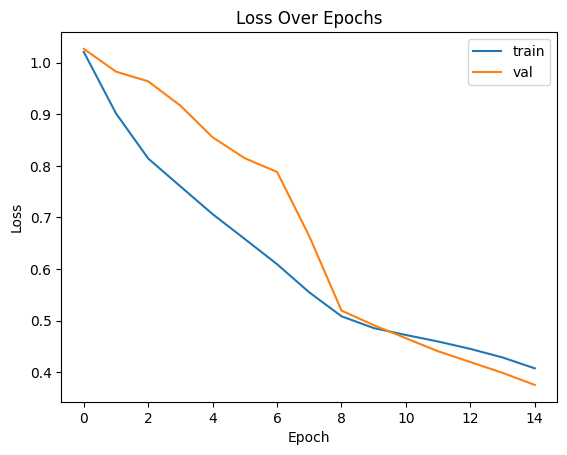

In [6]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {acc:.2f}")

# Plot loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()